#### Classificação de Imagens de Câncer de Mama com CNN e Grad-CAM (Keras)

Este notebook demonstra um pipeline completo em Python + Keras (TensorFlow) para:
1. Carregar um dataset de imagens a partir de dois diretórios.
2. Treinar um modelo de Deep Learning (CNN).
3. Avaliar o modelo.
4. Gerar visualizações de interpretabilidade utilizando Grad-CAM.

Estrutura esperada do dataset

dataset_root/ \
├── BreastCancer_Benign/ # classe 0 (negativa) \
└── BreastCancer_Maglinant/ # classe 1 (positiva)

1. Importação de bibliotecas

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from matplotlib import cm

2. Função para carregamento do dataset

In [2]:
def load_dataset(
    dataset_dir,
    img_size = (224, 224),
    batch_size = 32,
    test_size = 0.1,
    val_size = 0.1,
    random_state = 42):
    """
    Carrega imagens a partir de dois diretórios:
    - BreastCancer_Benign -> classe 0
    - BreastCancer_Maglinant -> classe 1
    """
    images = []
    labels = []
    class_mapping = {
        "BreastCancer_Benign": 0,
        "BreastCancer_Maglinant": 1
    }
    for class_name, label in class_mapping.items():
        class_dir = os.path.join(dataset_dir, class_name)
        for file in os.listdir(class_dir):
            file_path = os.path.join(class_dir, file)
            img = tf.keras.preprocessing.image.load_img(file_path, target_size = img_size)
            img_array = tf.keras.preprocessing.image.img_to_array(img)
            images.append(img_array)
            labels.append(label)
    X = np.array(images, dtype = "float32") / 255.0
    y = np.array(labels)
    # Split treino + teste
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = test_size, stratify = y, random_state = random_state)
    # Split treino + validação
    X_train, X_val, y_train, y_val = train_test_split(
        X_train,
        y_train,
        test_size = val_size,
        stratify = y_train,
        random_state = random_state
    )
    return X_train, X_val, X_test, y_train, y_val, y_test

3. Função para construção do modelo CNN

In [3]:
def build_model(input_shape = (224, 224, 3)):
    inputs = layers.Input(shape = input_shape, name = "input_layer")
    x = layers.Conv2D(16, (3, 3), activation = "relu")(inputs)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.Conv2D(32, (3, 3), activation = "relu")(x)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.Conv2D(
        64, (3, 3),
        activation = "relu",
        name = "last_conv_layer"
    )(x)
    x = layers.MaxPooling2D(2, 2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation = "relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation = "sigmoid")(x)
    model = models.Model(
        inputs = inputs,
        outputs = outputs,
        name = "cnn_binary_classifier"
    )
    model.compile(
        optimizer = Adam(learning_rate = 1e-4),
        loss = "binary_crossentropy",
        metrics = ["accuracy"]
    )
    return model

4. Função para treino do modelo

In [4]:
def train_model(model, X_train, y_train, X_val, y_val, epochs = 50, batch_size = 32):
    callbacks = [
        EarlyStopping(
            monitor = "val_loss",
            patience = 10,
            restore_best_weights = True,
            verbose = 1
        )
    ]
    history = model.fit(
        X_train, y_train,
        validation_data = (X_val, y_val),
        epochs = epochs,
        batch_size = batch_size,
        callbacks = callbacks
    )
    current_dir = os.getcwd()
    config_path = os.path.join(current_dir, 'modelconfig.keras')
    model.save(config_path)
    return history

5. Função para avaliação do modelo

In [5]:
def evaluate_model(model, X_test, y_test):
    loss, acc = model.evaluate(X_test, y_test, verbose = 0)
    print(f"\nTest Loss: {loss:.4f}")
    print(f"Test Accuracy: {acc:.4f}")
    y_pred = (model.predict(X_test) > 0.5).astype("int32")
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))
    print("\nConfusion Matrix:\n")
    print(confusion_matrix(y_test, y_pred))

6. Funções Grad-CAM

In [6]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs = model.input,
        outputs = [
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_index = tf.argmax(predictions[0])
        loss = predictions[:, class_index]
        grads = tape.gradient(loss, conv_outputs)
        pooled_grads = tf.reduce_mean(grads, axis = (0, 1, 2))
        conv_outputs = conv_outputs[0]
        heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)
        heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)
    return heatmap.numpy()

def apply_gradcam_and_show(img, heatmap, alpha = 0.4):
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap) if np.max(heatmap) != 0 else 1
    colormap = cm.get_cmap("jet")
    heatmap_rgb = colormap(heatmap)
    heatmap_rgb = np.delete(heatmap_rgb, 3, axis = 2)
    heatmap_rgb = tf.image.resize(heatmap_rgb, (img.shape[0], img.shape[1])).numpy()
    img_norm = img.astype("float32")
    if img_norm.max() > 1:
        img_norm /= 255.0
    superimposed = heatmap_rgb * alpha + img_norm
    superimposed = np.clip(superimposed, 0, 1)
    plt.figure(figsize = (10,5))
    plt.subplot(1,2,1)
    plt.title("Original")
    plt.imshow(img_norm)
    plt.axis("off")
    plt.subplot(1,2,2)
    plt.title("Grad-CAM")
    plt.imshow(superimposed)
    plt.axis("off")
    plt.show()

7. Execução do pipeline completo

In [7]:
DATASET_DIR = "dataset_root"

X_train, X_val, X_test, y_train, y_val, y_test = load_dataset(DATASET_DIR)
model = build_model(input_shape = X_train.shape[1:])
model.summary()
history = train_model(model, X_train, y_train, X_val, y_val)
evaluate_model(model, X_test, y_test)

Model: "cnn_binary_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 222, 222, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ last_conv_layer (Conv2D)             │ (None, 52, 52, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 43264)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       2,768,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,792,609 (10.65 MB)

 Trainable params: 2,792,609 (10.65 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 68s 333ms/step - accuracy: 0.6661 - loss: 0.6389 - val_accuracy: 0.6696 - val_loss: 0.6324
Epoch 2/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 71s 367ms/step - accuracy: 0.6698 - loss: 0.6331 - val_accuracy: 0.6696 - val_loss: 0.6282
Epoch 3/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 62s 318ms/step - accuracy: 0.6698 - loss: 0.6238 - val_accuracy: 0.6696 - val_loss: 0.6205
Epoch 4/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 62s 320ms/step - accuracy: 0.6698 - loss: 0.6148 - val_accuracy: 0.6696 - val_loss: 0.6110
Epoch 5/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 62s 317ms/step - accuracy: 0.6704 - loss: 0.5990 - val_accuracy: 0.6710 - val_loss: 0.5985
Epoch 6/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 63s 326ms/step - accuracy: 0.6842 - loss: 0.5741 - val_accuracy: 0.6798 - val_loss: 0.5693
Epoch 7/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 65s 334ms/step - accuracy: 0.7130 - loss: 0.5424 - val_accuracy: 0.7103 - val_loss: 0.5489
Epoch 8/50
194/194 ━━━━━━━━━━━━━━━━━━━━ 67s 344ms/step - accuracy: 0.7453 - loss: 0

8. Aplicação do Grad-CAM em uma imagem de teste

C:\Users\RodrigoAlexandre\AppData\Local\Temp\ipykernel_8100\792927265.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap("jet")


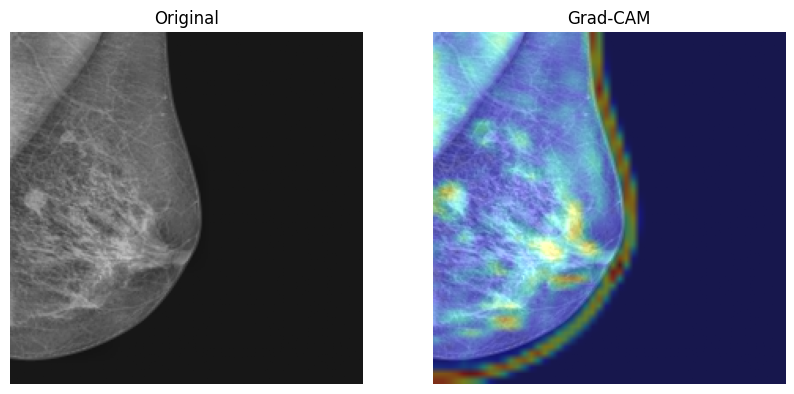

In [8]:
# Carregar a configuração do modelo já treinado.
current_dir = os.getcwd()
config_path = os.path.join(current_dir, 'modelconfig.keras')
loaded_model = keras.models.load_model(config_path)

# Selecionar uma imagem de teste.
idx = 0
img = X_test[idx]
img_array = np.expand_dims(img, axis = 0)

# Aplicar o Grad-CAM.
heatmap = make_gradcam_heatmap(
    img_array,
    loaded_model,
    last_conv_layer_name = "last_conv_layer"
)
apply_gradcam_and_show(img, heatmap)

In [9]:

# Connfirmar que a imagem utilizada foi predita pelo modelo como malígna (classe positiva).
y_pred = (loaded_model.predict(img_array) > 0.5).astype("int32")
print(y_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
[[1]]
